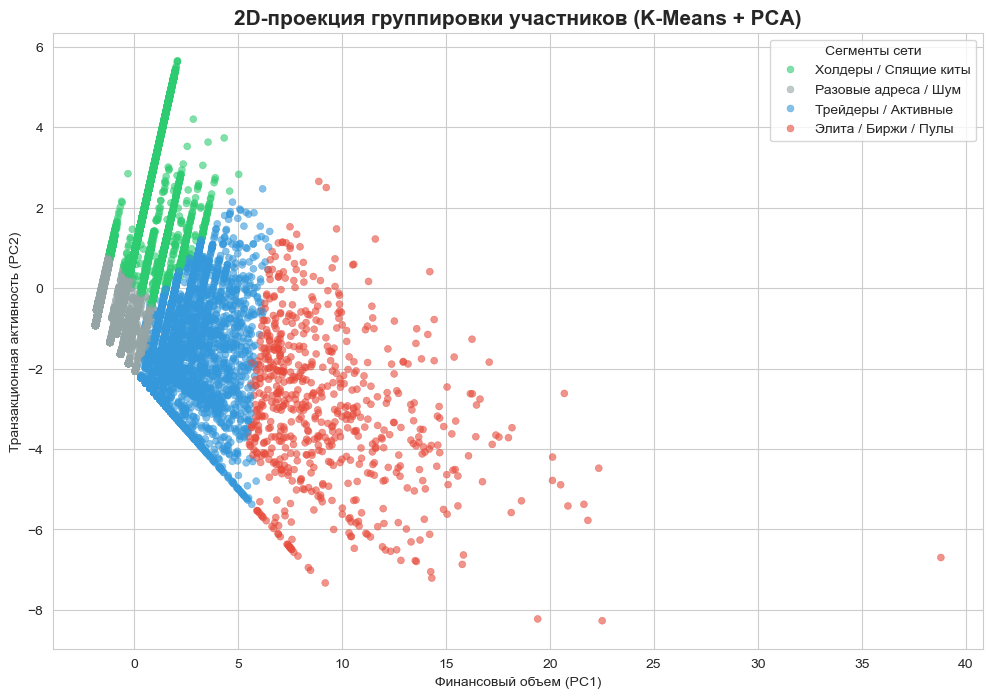

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('bitcoin_clustered_users.csv')

features = ['Total_Received_BTC', 'Num_Receives', 'Total_Spent_BTC', 'Num_Spends', 'Total_Tx']
X = df[features].copy()
for col in features:
    X[col] = np.log1p(X[col])

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_res, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# (Чтобы график совпал с твоей таблицей)
# Мы находим средние транзакции для каждого ID, который выдал код СЕЙЧАС
stats = df.groupby('Cluster')['Total_Tx'].mean().sort_values(ascending=False)

# Сопоставляем текущие ID с твоими названиями из диплома
# Самый активный -> Элита, Второй -> Активные и т.д.
mapping = {
    stats.index[0]: 'Элита / Биржи / Пулы',
    stats.index[1]: 'Трейдеры / Активные',
    stats.index[2]: 'Холдеры / Спящие киты',
    stats.index[3]: 'Разовые адреса / Шум'
}

df_plot = df_pca.sample(n=50000, random_state=42)
df_plot['Тип пользователя'] = df_plot['Cluster'].map(mapping)

palette = {
    'Элита / Биржи / Пулы': '#e74c3c', 'Трейдеры / Активные': '#3498db',
    'Холдеры / Спящие киты': '#2ecc71', 'Разовые адреса / Шум': '#95a5a6'
}

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
sns.scatterplot(x='PC1', y='PC2', hue='Тип пользователя', palette=palette, 
                data=df_plot, alpha=0.6, s=25, edgecolor=None)

plt.title('2D-проекция группировки участников (K-Means + PCA)', fontsize=15, fontweight='bold')
plt.xlabel('Финансовый объем (PC1)')
plt.ylabel('Транзакционная активность (PC2)')
plt.legend(title='Сегменты сети', loc='best')
plt.savefig('cluster_visualization.png', dpi=300)
plt.show()

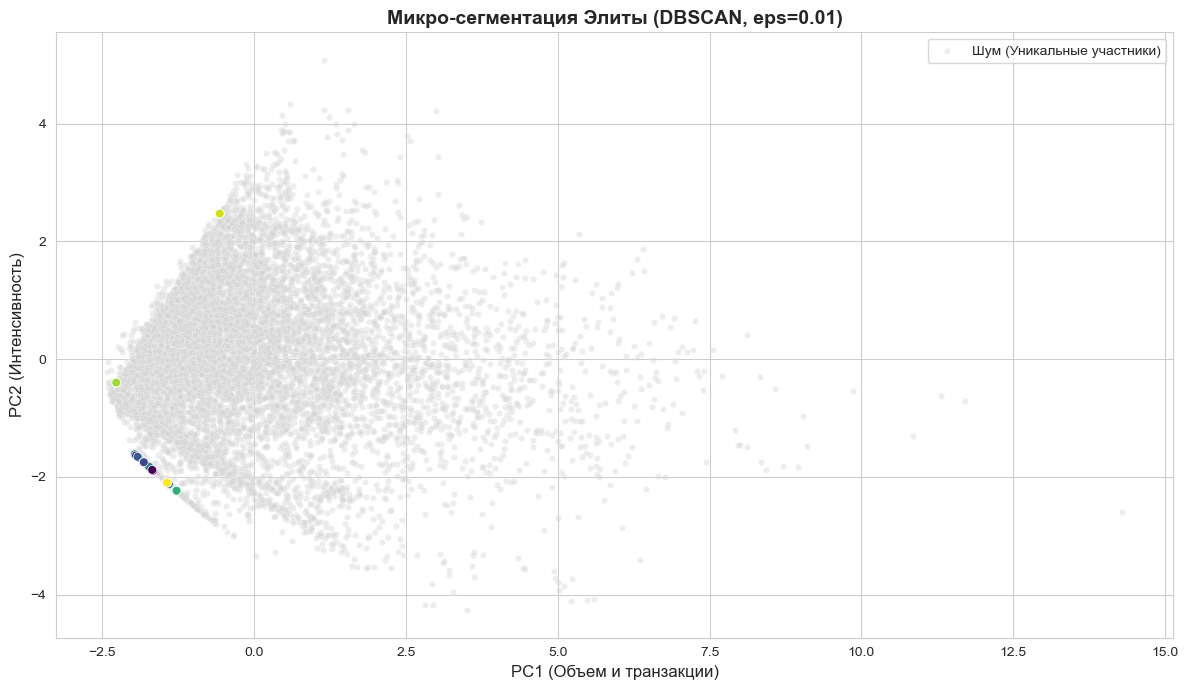

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

df = pd.read_csv('bitcoin_clustered_users.csv')

# Авто-определение кластера "Элита" (самый активный по транзакциям)
elite_id = df.groupby('Cluster')['Total_Tx'].mean().idxmax()
df_elite = df[df['Cluster'] == elite_id].copy()

#  (Логарифмирование + Масштабирование)
features = ['Total_Received_BTC', 'Num_Receives', 'Total_Spent_BTC', 'Num_Spends', 'Total_Tx']
X = df_elite[features].copy()
for col in features:
    X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  Применение DBSCAN (те самые параметры для поиска ботов)
dbscan = DBSCAN(eps=0.01, min_samples=5)
df_elite['SubCluster'] = dbscan.fit_predict(X_scaled)


pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_res, columns=['PC1', 'PC2'])
df_pca['SubCluster'] = df_elite['SubCluster'].values

df_pca['Status'] = df_pca['SubCluster'].apply(lambda x: 'Шум (Реальные игроки)' if x == -1 else 'Синтетический паттерн')

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Сначала рисуем шум (серым), потом паттерны (ярким цветом), чтобы они были сверху
sns.scatterplot(data=df_pca[df_pca['Status'] == 'Шум (Реальные игроки)'], 
                x='PC1', y='PC2', color='lightgrey', alpha=0.4, s=20, label='Шум (Уникальные участники)')

sns.scatterplot(data=df_pca[df_pca['Status'] == 'Синтетический паттерн'], 
                x='PC1', y='PC2', hue='SubCluster', palette='viridis', s=40, legend=False)

plt.title(f'Микро-сегментация Элиты (DBSCAN, eps=0.01)', 
          fontsize=14, fontweight='bold')
plt.xlabel('PC1 (Объем и транзакции)', fontsize=12)
plt.ylabel('PC2 (Интенсивность)', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('dbscan_2d_visualization.png', dpi=300)
plt.show()